# Phase 3: Predictive Modeling


## Data Validation and Preparation

In [246]:
import pandas as pd
from pathlib import Path
import numpy as np

In [247]:
DATA_PATH = Path("../data/processed/team_game_logs_clean.csv")

df = pd.read_csv(
    DATA_PATH,
    dtype={
        "GAME_ID": "string",
        "SEASON": "string",
        "TEAM_ID": "Int64",
    },
    parse_dates=["GAME_DATE"],
)

print(df.shape)
df.head()

(12300, 36)


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,PTS,PLUS_MINUS,VIDEO_AVAILABLE,SEASON,SEASON_TYPE,WIN,HOME_GAME,AWAY_GAME,OPPONENT_ABBREVIATION,TEAM_GAME_NUMBER
0,22021,1610612749,MIL,Milwaukee Bucks,0022100001,2021-10-19,MIL vs. BKN,W,240,48,...,127,23,1,2021-22,Regular Season,1,1,0,BKN,1
1,22021,1610612751,BKN,Brooklyn Nets,0022100001,2021-10-19,BKN @ MIL,L,240,37,...,104,-23,1,2021-22,Regular Season,0,0,1,MIL,1
2,22021,1610612744,GSW,Golden State Warriors,0022100002,2021-10-19,GSW @ LAL,W,240,41,...,121,7,1,2021-22,Regular Season,1,0,1,LAL,1
3,22021,1610612747,LAL,Los Angeles Lakers,0022100002,2021-10-19,LAL vs. GSW,L,240,45,...,114,-7,1,2021-22,Regular Season,0,1,0,GSW,1
4,22021,1610612754,IND,Indiana Pacers,0022100003,2021-10-20,IND @ CHA,L,240,42,...,122,-1,1,2021-22,Regular Season,0,0,1,CHA,1


In [248]:
'''Check columns'''
df.columns.tolist()

['SEASON_ID',
 'TEAM_ID',
 'TEAM_ABBREVIATION',
 'TEAM_NAME',
 'GAME_ID',
 'GAME_DATE',
 'MATCHUP',
 'WL',
 'MIN',
 'FGM',
 'FGA',
 'FG_PCT',
 'FG3M',
 'FG3A',
 'FG3_PCT',
 'FTM',
 'FTA',
 'FT_PCT',
 'OREB',
 'DREB',
 'REB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PTS',
 'PLUS_MINUS',
 'VIDEO_AVAILABLE',
 'SEASON',
 'SEASON_TYPE',
 'WIN',
 'HOME_GAME',
 'AWAY_GAME',
 'OPPONENT_ABBREVIATION',
 'TEAM_GAME_NUMBER']

In [249]:
'''Check required columns'''
required_columns = [
    "SEASON",
    "GAME_ID",
    "GAME_DATE",
    "TEAM_ID",
    "TEAM_NAME",
    "MATCHUP",
    "WL",
    "WIN",
    "HOME_GAME",
    "AWAY_GAME",
    "OPPONENT_ABBREVIATION",
    "TEAM_GAME_NUMBER",
    "PTS",
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


In [250]:
'''Check data range'''
print("First game:", df["GAME_DATE"].min())
print("Last game:", df["GAME_DATE"].max())

First game: 2021-10-19 00:00:00
Last game: 2026-04-12 00:00:00


In [251]:
'''Check duplicate team rows'''
print("Duplicate team-game rows:")
print(df.duplicated(["GAME_ID", "TEAM_ID"]).sum())
'''Check missing target values'''
print("\nMissing target values:")
print(df["WIN"].isna().sum())


Duplicate team-game rows:
0

Missing target values:
0


In [252]:
'''Check missing values and number of teams'''
print("\nMissing values:")
print(df.isna().sum())

'''Check number of teams'''
df.groupby("SEASON")["TEAM_ID"].nunique()


Missing values:
SEASON_ID                0
TEAM_ID                  0
TEAM_ABBREVIATION        0
TEAM_NAME                0
GAME_ID                  0
GAME_DATE                0
MATCHUP                  0
WL                       0
MIN                      0
FGM                      0
FGA                      0
FG_PCT                   0
FG3M                     0
FG3A                     0
FG3_PCT                  0
FTM                      0
FTA                      0
FT_PCT                   1
OREB                     0
DREB                     0
REB                      0
AST                      0
STL                      0
BLK                      0
TOV                      0
PF                       0
PTS                      0
PLUS_MINUS               0
VIDEO_AVAILABLE          0
SEASON                   0
SEASON_TYPE              0
WIN                      0
HOME_GAME                0
AWAY_GAME                0
OPPONENT_ABBREVIATION    0
TEAM_GAME_NUMBER         0
dtype: int6

SEASON
2021-22    30
2022-23    30
2023-24    30
2024-25    30
2025-26    30
Name: TEAM_ID, dtype: int64

In [253]:
'''Check summary statistics'''
season_summary = (
    df.groupby("SEASON")
    .agg(
        TEAM_GAME_ROWS=("GAME_ID", "size"),
        UNIQUE_GAMES=("GAME_ID", "nunique"),
        TEAMS=("TEAM_ID", "nunique"),
        FIRST_GAME=("GAME_DATE", "min"),
        LAST_GAME=("GAME_DATE", "max"),
    )
    .reset_index()
)

season_summary

,SEASON,TEAM_GAME_ROWS,UNIQUE_GAMES,TEAMS,FIRST_GAME,LAST_GAME
0,2021-22,2460,1230,30,2021-10-19,2022-04-10
1,2022-23,2460,1230,30,2022-10-18,2023-04-09
2,2023-24,2460,1230,30,2023-10-24,2024-04-14
3,2024-25,2460,1230,30,2024-10-22,2025-04-13
4,2025-26,2460,1230,30,2025-10-21,2026-04-12


### Set Up Rolling Features

In [254]:
df = (
    df.sort_values(
        [
            "TEAM_ID",
            "SEASON",
            "GAME_DATE",
            "GAME_ID",
        ]
    )
    .reset_index(drop=True)
)

df.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,PTS,PLUS_MINUS,VIDEO_AVAILABLE,SEASON,SEASON_TYPE,WIN,HOME_GAME,AWAY_GAME,OPPONENT_ABBREVIATION,TEAM_GAME_NUMBER
0,22021,1610612737,ATL,Atlanta Hawks,0022100014,2021-10-21,ATL vs. DAL,W,240,45,...,113,26,1,2021-22,Regular Season,1,1,0,DAL,1
1,22021,1610612737,ATL,Atlanta Hawks,0022100027,2021-10-23,ATL @ CLE,L,240,38,...,95,-6,1,2021-22,Regular Season,0,0,1,CLE,2
2,22021,1610612737,ATL,Atlanta Hawks,0022100043,2021-10-25,ATL vs. DET,W,240,46,...,122,18,1,2021-22,Regular Season,1,1,0,DET,3
3,22021,1610612737,ATL,Atlanta Hawks,0022100059,2021-10-27,ATL @ NOP,W,240,40,...,102,3,1,2021-22,Regular Season,1,0,1,NOP,4
4,22021,1610612737,ATL,Atlanta Hawks,0022100066,2021-10-28,ATL @ WAS,L,240,48,...,111,-11,1,2021-22,Regular Season,0,0,1,WAS,5


In [255]:
df["PREV_WIN"] = (
    df.groupby(["SEASON", "TEAM_ID"])["WIN"]
      .shift(1)
)

df["PREV_PTS"] = (
    df.groupby(["SEASON", "TEAM_ID"])["PTS"]
      .shift(1)
)

df["PREV_WINS"] = (
    df.groupby(["SEASON", "TEAM_ID"])["WIN"]
      .cumsum()
      - df["WIN"]
)

df["PREV_GAMES"] = (
    df.groupby(["SEASON", "TEAM_ID"])
      .cumcount()
)

df["SEASON_WIN_PCT"] = (
    df["PREV_WINS"] / df["PREV_GAMES"]
)
df.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,WIN,HOME_GAME,AWAY_GAME,OPPONENT_ABBREVIATION,TEAM_GAME_NUMBER,PREV_WIN,PREV_PTS,PREV_WINS,PREV_GAMES,SEASON_WIN_PCT
0,22021,1610612737,ATL,Atlanta Hawks,0022100014,2021-10-21,ATL vs. DAL,W,240,45,...,1,1,0,DAL,1,NaN,NaN,0,0,NaN
1,22021,1610612737,ATL,Atlanta Hawks,0022100027,2021-10-23,ATL @ CLE,L,240,38,...,0,0,1,CLE,2,1.0,113.0,1,1,1.000000
2,22021,1610612737,ATL,Atlanta Hawks,0022100043,2021-10-25,ATL vs. DET,W,240,46,...,1,1,0,DET,3,0.0,95.0,1,2,0.500000
3,22021,1610612737,ATL,Atlanta Hawks,0022100059,2021-10-27,ATL @ NOP,W,240,40,...,1,0,1,NOP,4,1.0,122.0,2,3,0.666667
4,22021,1610612737,ATL,Atlanta Hawks,0022100066,2021-10-28,ATL @ WAS,L,240,48,...,0,0,1,WAS,5,1.0,102.0,3,4,0.750000


In [256]:
rolling_columns = [
    "PTS",
    "FG_PCT",
    "FG3_PCT",
    "FT_PCT",
    "REB",
    "AST",
    "STL",
    "BLK",
    "TOV",
    "PLUS_MINUS",
]

for column in rolling_columns:

    df[f"{column}_ROLL5"] = (
        df.groupby(["SEASON", "TEAM_ID"])[column]
          .transform(
              lambda x:
              x.shift(1)
               .rolling(
                   window=5,
                   min_periods=1,
               )
               .mean()
          )
    )

df["WIN_PCT_ROLL5"] = (
    df.groupby(["SEASON", "TEAM_ID"])["WIN"]
      .transform(
          lambda x:
          x.shift(1)
           .rolling(
               window=5,
               min_periods=1,
           )
           .mean()
      )
)
df.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,FG_PCT_ROLL5,FG3_PCT_ROLL5,FT_PCT_ROLL5,REB_ROLL5,AST_ROLL5,STL_ROLL5,BLK_ROLL5,TOV_ROLL5,PLUS_MINUS_ROLL5,WIN_PCT_ROLL5
0,22021,1610612737,ATL,Atlanta Hawks,0022100014,2021-10-21,ATL vs. DAL,W,240,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22021,1610612737,ATL,Atlanta Hawks,0022100027,2021-10-23,ATL @ CLE,L,240,38,...,0.47900,0.42900,0.8890,55.000000,31.0,8.0,9.00,13.000000,26.000000,1.000000
2,22021,1610612737,ATL,Atlanta Hawks,0022100043,2021-10-25,ATL vs. DET,W,240,46,...,0.43150,0.36150,0.7445,54.500000,25.5,6.5,6.00,11.000000,10.000000,0.500000
3,22021,1610612737,ATL,Atlanta Hawks,0022100059,2021-10-27,ATL @ NOP,W,240,40,...,0.45800,0.36600,0.7820,52.666667,25.0,8.0,5.00,12.666667,12.666667,0.666667
4,22021,1610612737,ATL,Atlanta Hawks,0022100066,2021-10-28,ATL @ WAS,L,240,48,...,0.44775,0.34125,0.7925,53.250000,24.0,7.0,4.75,12.250000,10.250000,0.750000


In [257]:
df["WIN_PCT_ROLL5"] = (
    df.groupby(["SEASON", "TEAM_ID"])["WIN"]
      .transform(
          lambda x:
          x.shift(1)
           .rolling(
               window=5,
               min_periods=1,
           )
           .mean()
      )
)

df["REST_DAYS"] = (
    df.groupby(["SEASON", "TEAM_ID"])["GAME_DATE"]
      .diff()
      .dt.days
)

df["WIN_STREAK"] = (
    df.groupby(["SEASON", "TEAM_ID"])["WIN"]
      .transform(
          lambda x: (
              x.shift(1)
               .fillna(0)
               .groupby(
                   (
                       x.shift(1)
                       != x.shift(1).shift()
                   ).cumsum()
               )
               .cumsum()
          )
      )
)

df.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,FT_PCT_ROLL5,REB_ROLL5,AST_ROLL5,STL_ROLL5,BLK_ROLL5,TOV_ROLL5,PLUS_MINUS_ROLL5,WIN_PCT_ROLL5,REST_DAYS,WIN_STREAK
0,22021,1610612737,ATL,Atlanta Hawks,0022100014,2021-10-21,ATL vs. DAL,W,240,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,22021,1610612737,ATL,Atlanta Hawks,0022100027,2021-10-23,ATL @ CLE,L,240,38,...,0.8890,55.000000,31.0,8.0,9.00,13.000000,26.000000,1.000000,2.0,1.0
2,22021,1610612737,ATL,Atlanta Hawks,0022100043,2021-10-25,ATL vs. DET,W,240,46,...,0.7445,54.500000,25.5,6.5,6.00,11.000000,10.000000,0.500000,2.0,0.0
3,22021,1610612737,ATL,Atlanta Hawks,0022100059,2021-10-27,ATL @ NOP,W,240,40,...,0.7820,52.666667,25.0,8.0,5.00,12.666667,12.666667,0.666667,2.0,1.0
4,22021,1610612737,ATL,Atlanta Hawks,0022100066,2021-10-28,ATL @ WAS,L,240,48,...,0.7925,53.250000,24.0,7.0,4.75,12.250000,10.250000,0.750000,1.0,2.0


### Opponent Features

In [258]:
opponent_feature_columns = [
    "PTS_ROLL5",
    "FG_PCT_ROLL5",
    "FG3_PCT_ROLL5",
    "FT_PCT_ROLL5",
    "REB_ROLL5",
    "AST_ROLL5",
    "STL_ROLL5",
    "BLK_ROLL5",
    "TOV_ROLL5",
    "PLUS_MINUS_ROLL5",
    "WIN_PCT_ROLL5",
    "REST_DAYS",
]

opponent_df = df[
    [
        "SEASON",
        "GAME_ID",
        "TEAM_ID",
        "TEAM_NAME",
        *opponent_feature_columns,
    ]
].copy()

opponent_df = opponent_df.rename(
    columns={
        "TEAM_ID": "OPPONENT_TEAM_ID",
        "TEAM_NAME": "OPPONENT_TEAM_NAME",
        **{
            column: f"OPP_{column}"
            for column in opponent_feature_columns
        },
    }
)

df = df.merge(
    opponent_df,
    on=[
        "SEASON",
        "GAME_ID",
    ],
    how="left",
)

df = df[
    df["TEAM_ID"] != df["OPPONENT_TEAM_ID"]
].copy()

df = df.reset_index(drop=True)

In [259]:
print(df.shape)

df[
    [
        "GAME_ID",
        "TEAM_NAME",
        "OPPONENT_TEAM_NAME",
        "PTS_ROLL5",
        "OPP_PTS_ROLL5",
        "WIN_PCT_ROLL5",
        "OPP_WIN_PCT_ROLL5",
    ]
].head(10)

(12300, 68)


,GAME_ID,TEAM_NAME,OPPONENT_TEAM_NAME,PTS_ROLL5,OPP_PTS_ROLL5,WIN_PCT_ROLL5,OPP_WIN_PCT_ROLL5
0,0022100014,Atlanta Hawks,Dallas Mavericks,NaN,NaN,NaN,NaN
1,0022100027,Atlanta Hawks,Cleveland Cavaliers,113.0,116.50,1.000000,0.00
2,0022100043,Atlanta Hawks,Detroit Pistons,104.0,85.00,0.500000,0.00
3,0022100059,Atlanta Hawks,New Orleans Pelicans,110.0,101.25,0.666667,0.25
4,0022100066,Atlanta Hawks,Washington Wizards,108.0,109.75,0.750000,0.75
5,0022100082,Atlanta Hawks,Philadelphia 76ers,108.6,110.00,0.600000,0.60
6,0022100097,Atlanta Hawks,Washington Wizards,104.8,115.60,0.400000,0.80
7,0022100113,Atlanta Hawks,Brooklyn Nets,109.4,102.80,0.600000,0.60
8,0022100120,Atlanta Hawks,Utah Jazz,106.6,113.80,0.400000,0.80
9,0022100137,Atlanta Hawks,Phoenix Suns,105.8,109.60,0.200000,0.60


In [260]:
'''Check number of game_id per game to be 2'''
df.groupby(
    [
        "SEASON",
        "GAME_ID",
    ]
).size().value_counts()

2    6150
Name: count, dtype: int64

In [261]:
df["PTS_ROLL5_DIFF"] = (
    df["PTS_ROLL5"]
    - df["OPP_PTS_ROLL5"]
)

df["FG_PCT_ROLL5_DIFF"] = (
    df["FG_PCT_ROLL5"]
    - df["OPP_FG_PCT_ROLL5"]
)

df["FG3_PCT_ROLL5_DIFF"] = (
    df["FG3_PCT_ROLL5"]
    - df["OPP_FG3_PCT_ROLL5"]
)

df["REB_ROLL5_DIFF"] = (
    df["REB_ROLL5"]
    - df["OPP_REB_ROLL5"]
)

df["AST_ROLL5_DIFF"] = (
    df["AST_ROLL5"]
    - df["OPP_AST_ROLL5"]
)

df["TOV_ROLL5_DIFF"] = (
    df["TOV_ROLL5"]
    - df["OPP_TOV_ROLL5"]
)

df["PLUS_MINUS_ROLL5_DIFF"] = (
    df["PLUS_MINUS_ROLL5"]
    - df["OPP_PLUS_MINUS_ROLL5"]
)

df["WIN_PCT_ROLL5_DIFF"] = (
    df["WIN_PCT_ROLL5"]
    - df["OPP_WIN_PCT_ROLL5"]
)

df["REST_DAYS_DIFF"] = (
    df["REST_DAYS"]
    - df["OPP_REST_DAYS"]
)

### Save Modeling Dataset

In [262]:
output_path = Path(
    "../data/processed/team_game_modeling.csv"
)

df.to_csv(
    output_path,
    index=False,
)

print(f"Saved to: {output_path}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")

Saved to: ../data/processed/team_game_modeling.csv
Rows: 12,300
Columns: 77


## Model Preparation

### Train/Test Split

In [263]:
train_df = df[df["SEASON"] != "2025-26"].copy()

test_df = df[df["SEASON"] == "2025-26"].copy()

### Choosing Features and Target

In [264]:
features = [
    # Location
    "HOME_GAME",
    "REST_DAYS",

    # Team season performance
    "SEASON_WIN_PCT",
    "TEAM_GAME_NUMBER",

    # Recent form
    "PTS_ROLL5",
    "FG_PCT_ROLL5",
    "FG3_PCT_ROLL5",
    "FT_PCT_ROLL5",
    "REB_ROLL5",
    "AST_ROLL5",
    "STL_ROLL5",
    "BLK_ROLL5",
    "TOV_ROLL5",
    "PLUS_MINUS_ROLL5",
    "WIN_PCT_ROLL5",

    # Opponent recent form
    "OPP_PTS_ROLL5",
    "OPP_FG_PCT_ROLL5",
    "OPP_FG3_PCT_ROLL5",
    "OPP_FT_PCT_ROLL5",
    "OPP_REB_ROLL5",
    "OPP_AST_ROLL5",
    "OPP_STL_ROLL5",
    "OPP_BLK_ROLL5",
    "OPP_TOV_ROLL5",
    "OPP_PLUS_MINUS_ROLL5",
    "OPP_WIN_PCT_ROLL5",
    "OPP_REST_DAYS",

    # Team vs opponent
    "PTS_ROLL5_DIFF",
    "FG_PCT_ROLL5_DIFF",
    "FG3_PCT_ROLL5_DIFF",
    "REB_ROLL5_DIFF",
    "AST_ROLL5_DIFF",
    "TOV_ROLL5_DIFF",
    "PLUS_MINUS_ROLL5_DIFF",
    "WIN_PCT_ROLL5_DIFF",
    "REST_DAYS_DIFF",
]

In [265]:
target = "WIN"

In [266]:
'''Drop rows with missing feature values'''
train_df = train_df.dropna(subset=features)

test_df = test_df.dropna(subset=features)

### Split X and Y

For this model, we will be using the 2021-2025 season to test 2025-2026 season predictions and results

In [267]:
train_df = df[df["SEASON"] != "2025-26"].copy()
test_df = df[df["SEASON"] == "2025-26"].copy()

print(train_df["SEASON"].value_counts().sort_index())
print()
print(test_df["SEASON"].value_counts().sort_index())

SEASON
2021-22    2460
2022-23    2460
2023-24    2460
2024-25    2460
Name: count, dtype: Int64

SEASON
2025-26    2460
Name: count, dtype: Int64


In [268]:
train_df = train_df.dropna(subset=features)
test_df = test_df.dropna(subset=features)

print(len(train_df))
print(len(test_df))

9714
2428


In [269]:
X_train = train_df[features]

y_train = train_df[target]

X_test = test_df[features]

y_test = test_df[target]

In [270]:
print("Training Features:", X_train.shape)
print("Training Labels:", y_train.shape)

print()

print("Testing Features:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Features: (9714, 36)
Training Labels: (9714,)

Testing Features: (2428, 36)
Testing Labels: (2428,)


## Logistic Regression

In [271]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

### Build Model

In [272]:
logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000,
            ),
        ),
    ]
)


### Train

In [273]:
logistic_model.fit(
    X_train,
    y_train,
)

print("Training complete.")

Training complete.


### Coefficients

In [274]:
import pandas as pd

coefficients = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Coefficient": logistic_model.named_steps["classifier"].coef_[0],
    }
)

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
2,SEASON_WIN_PCT,0.373497
0,HOME_GAME,0.226107
33,PLUS_MINUS_ROLL5_DIFF,0.186642
35,REST_DAYS_DIFF,0.090764
13,PLUS_MINUS_ROLL5,0.090348
23,OPP_TOV_ROLL5,0.049906
28,FG_PCT_ROLL5_DIFF,0.047206
1,REST_DAYS,0.046941
7,FT_PCT_ROLL5,0.032617
5,FG_PCT_ROLL5,0.030430


#### Multicollinearity Analysis

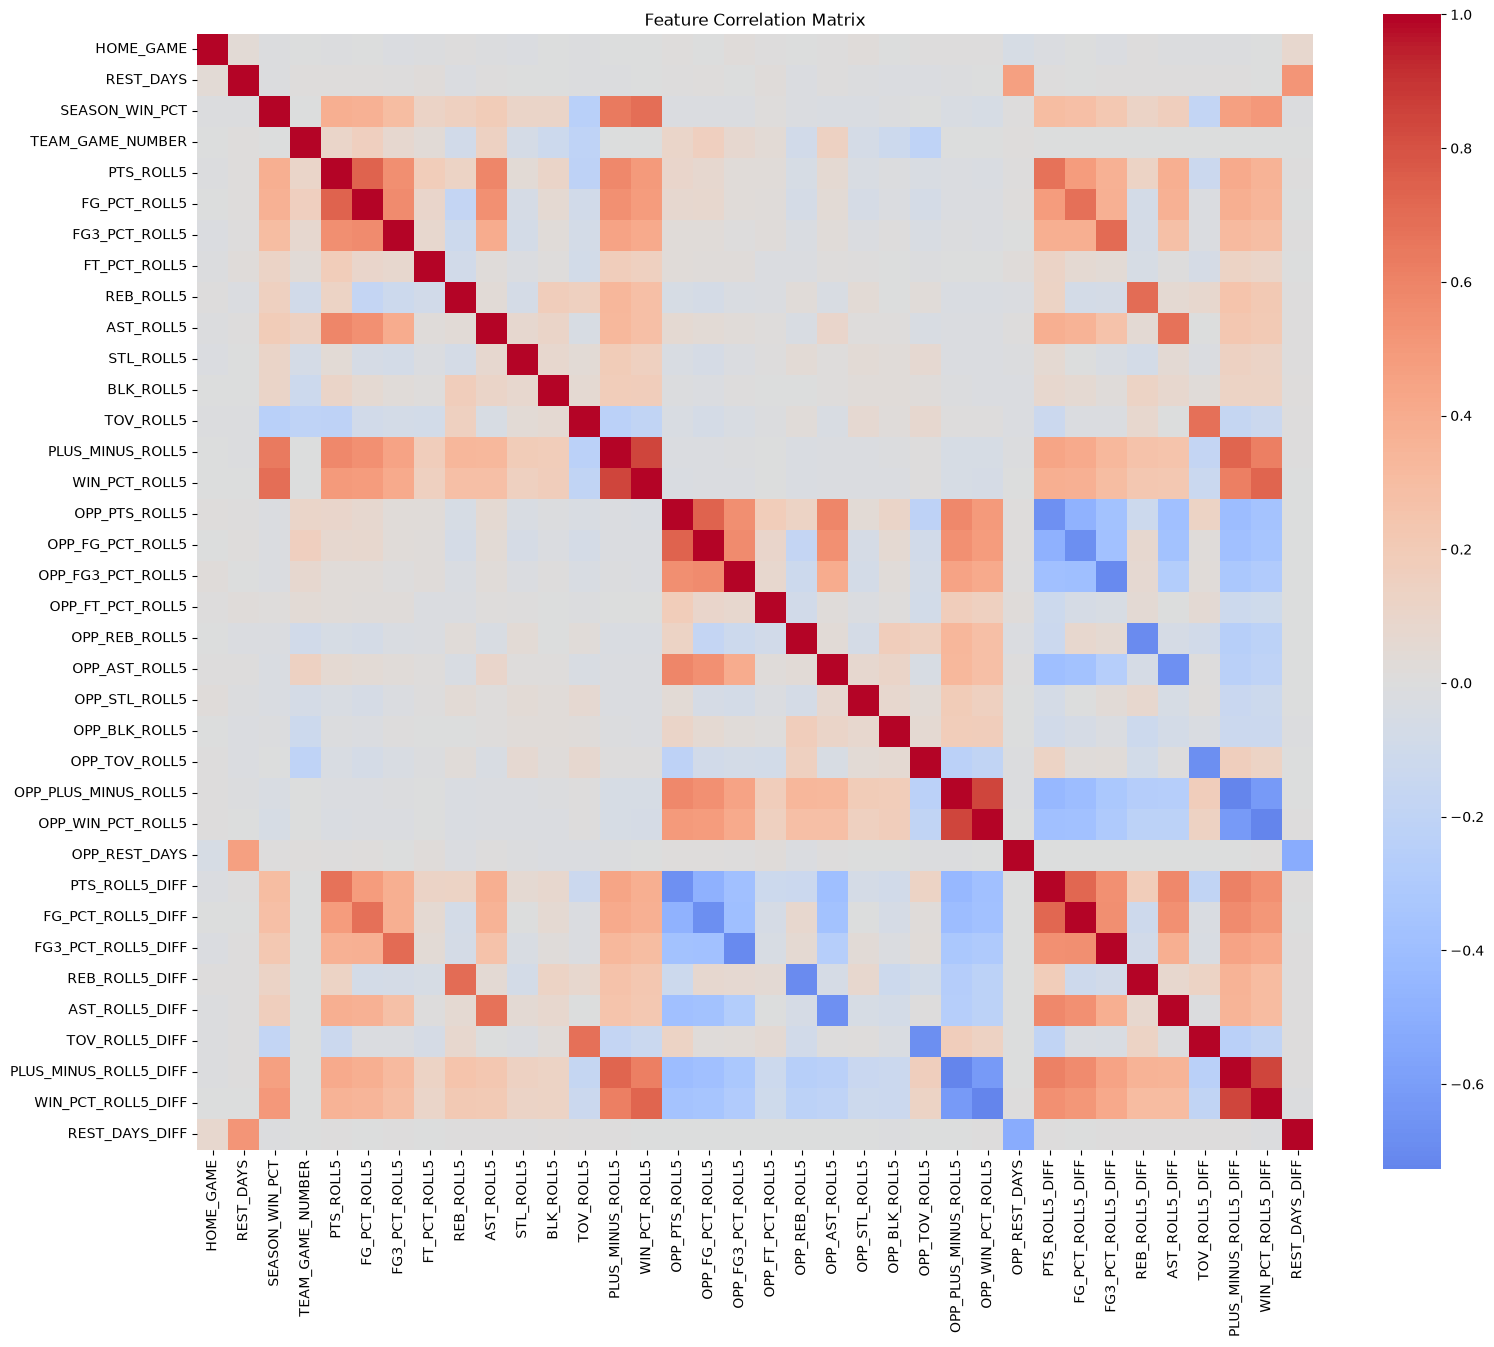

In [275]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = X_train.corr()

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Feature Correlation Matrix")
plt.show()

In [276]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .sort_values(ascending=False)
)

high_corr[high_corr > 0.75]

PLUS_MINUS_ROLL5_DIFF  WIN_PCT_ROLL5_DIFF    0.849563
PLUS_MINUS_ROLL5       WIN_PCT_ROLL5         0.846626
OPP_PLUS_MINUS_ROLL5   OPP_WIN_PCT_ROLL5     0.846626
dtype: float64

In [277]:
print(
    (
        X_train["PLUS_MINUS_ROLL5"]
        - X_train["OPP_PLUS_MINUS_ROLL5"]
        - X_train["PLUS_MINUS_ROLL5_DIFF"]
    ).abs().max()
)

0.0


### Predict

In [278]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

logistic_model.predict(X_test)
logistic_model.predict_proba(X_test)

array([[0.8570702 , 0.1429298 ],
       [0.58652854, 0.41347146],
       [0.72530274, 0.27469726],
       ...,
       [0.63618245, 0.36381755],
       [0.4166098 , 0.5833902 ],
       [0.68883596, 0.31116404]], shape=(2428, 2))

In [279]:
print(
    (
        X_train["PLUS_MINUS_ROLL5"]
        - X_train["OPP_PLUS_MINUS_ROLL5"]
        - X_train["PLUS_MINUS_ROLL5_DIFF"]
    ).abs().max()
)

0.0


### Evaluate

In [280]:
# Accuracy (correct predictions / total predictions)
accuracy = accuracy_score(y_test, y_pred)

# Precision (true positives / (true positives + false positives))   
precision = precision_score(y_test, y_pred)

# Recall (true positives / (true positives + false negatives))
recall = recall_score(y_test, y_pred)

# F1 Score (harmonic mean of precision and recall)
f1 = f1_score(y_test, y_pred)

# ROC AUC (area under the ROC curve)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"ROC AUC  : {roc_auc:.3f}")

Accuracy : 0.644
Precision: 0.643
Recall   : 0.647
F1 Score : 0.645
ROC AUC  : 0.711


### Notes:
The engineered differential features introduced perfect linear relationships with the corresponding team and opponent statistics. This resulted in infinite VIF values, indicating perfect multicollinearity. Because the primary objective was predictive performance rather than statistical inference, the complete feature set was retained. Logistic Regression uses L2 regularization to mitigate this issue, while tree-based models are generally less sensitive to multicollinearity.

## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier


Accuracy : 0.637
Precision: 0.647
Recall   : 0.603
F1 Score : 0.624
ROC AUC  : 0.691


### Build Model

In [306]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# reduced overfitting by setting max_depth

### Train

In [299]:
decision_tree.fit(X_train, y_train)

print("Training complete.")

Training complete.


### Predict

In [300]:
y_pred_tree = decision_tree.predict(X_test)

y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

### Evaluate

In [301]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)

tree_precision = precision_score(y_test, y_pred_tree)

tree_recall = recall_score(y_test, y_pred_tree)

tree_f1 = f1_score(y_test, y_pred_tree)

tree_auc = roc_auc_score(y_test, y_prob_tree)

print(f"Accuracy : {tree_accuracy:.3f}")
print(f"Precision: {tree_precision:.3f}")
print(f"Recall   : {tree_recall:.3f}")
print(f"F1 Score : {tree_f1:.3f}")
print(f"ROC AUC  : {tree_auc:.3f}")

Accuracy : 0.637
Precision: 0.647
Recall   : 0.603
F1 Score : 0.624
ROC AUC  : 0.691


#### Confusion Matrix

In [302]:
tree_cm = confusion_matrix(
    y_test,
    y_pred_tree
)

print(tree_cm)

[[815 399]
 [482 732]]


#### Classification Report

In [303]:
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

              precision    recall  f1-score   support

           0       0.63      0.67      0.65      1214
           1       0.65      0.60      0.62      1214

    accuracy                           0.64      2428
   macro avg       0.64      0.64      0.64      2428
weighted avg       0.64      0.64      0.64      2428



### Feature Importance

In [304]:
importance = (
    pd.DataFrame(
        {
            "Feature": X_train.columns,
            "Importance": decision_tree.feature_importances_,
        }
    )
    .sort_values("Importance", ascending=False)
)

importance

,Feature,Importance
33,PLUS_MINUS_ROLL5_DIFF,0.461061
2,SEASON_WIN_PCT,0.198891
0,HOME_GAME,0.101982
3,TEAM_GAME_NUMBER,0.055895
24,OPP_PLUS_MINUS_ROLL5,0.036935
35,REST_DAYS_DIFF,0.026001
16,OPP_FG_PCT_ROLL5,0.023451
32,TOV_ROLL5_DIFF,0.018150
17,OPP_FG3_PCT_ROLL5,0.012254
9,AST_ROLL5,0.009759


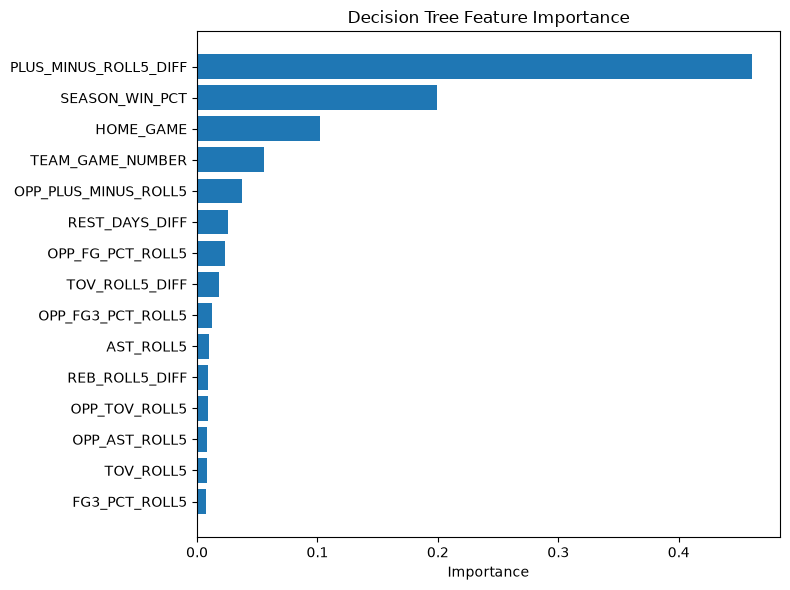

In [305]:
import matplotlib.pyplot as plt

top_features = (
    importance.head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
)

plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")

plt.tight_layout()
plt.show()

### Notes
The baseline Decision Tree substantially underperformed Logistic Regression, indicating that an unconstrained tree overfit the training data and failed to generalize well to the 2025–26 test season. Limiting the tree depth to five levels significantly improved performance, increasing accuracy from 55.0% to 63.7% and ROC AUC from 0.550 to 0.691. These results demonstrate the importance of controlling model complexity to reduce overfitting.

Feature importance analysis identified recent point differential (PLUS_MINUS_ROLL5_DIFF), season win percentage, and home court advantage as the most influential predictors, reinforcing conclusions drawn from the Logistic Regression model. However, despite the improvement, the tuned Decision Tree still performed slightly below Logistic Regression, suggesting that a single tree may not fully capture the complex relationships present in NBA game outcomes.

Because individual Decision Trees are prone to high variance and overfitting, the next step is to evaluate a Random Forest model, which combines predictions from many decision trees to improve generalization and predictive performance.

## Random Forest

## XGBoost